# Step 4: BERTweet — Zero-Shot Evaluation

**Model:** `vinai/bertweet-base` — pre-trained on 850M English tweets (VinAI Research)

**Task:** 3-class hate speech classification **without any fine-tuning**
- `0` = Normal
- `1` = Offensive  
- `2` = Hate

**Method:** Same as BERT-base-uncased — cosine similarity between [CLS] embeddings and label description embeddings.

**Key difference vs BERT-base-uncased:** BERTweet is pre-trained on tweets, so it understands social media language, slang, hashtags, @mentions, emojis better.

**Datasets:** HateXPlain + TweetEval (labels: 0=Normal, 1=Offensive, 2=Hate)

## 0. Install Dependencies

In [1]:
# Run once if needed
# !pip install transformers torch scikit-learn pandas numpy matplotlib seaborn emoji==1.7.0

In [2]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Load Datasets

In [5]:
HATEXPLAIN_PATH = 'HateXPlain_data/'
TWEETEVAL_PATH  = 'Tweeteval三类分/'

# HateXPlain
hx_test = pd.read_csv(HATEXPLAIN_PATH + 'test.csv')

# TweetEval
te_test = pd.read_csv(TWEETEVAL_PATH + 'test.csv')
te_test = te_test.rename(columns={'comment': 'text'})

LABEL_NAMES = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print('HateXPlain test size:', len(hx_test))
print('TweetEval test size: ', len(te_test))
print('\nHateXPlain label distribution:')
print(hx_test['label'].value_counts().sort_index())
print('\nTweetEval label distribution:')
print(te_test['label'].value_counts().sort_index())

HateXPlain test size: 2012
TweetEval test size:  3830

HateXPlain label distribution:
label
0    814
1    575
2    623
Name: count, dtype: int64

TweetEval label distribution:
label
0    2338
1     240
2    1252
Name: count, dtype: int64


## 3. Load BERTweet

BERTweet uses its own tokenizer with tweet-specific preprocessing (normalises URLs, @mentions, emojis).

In [6]:
MODEL_NAME = 'vinai/bertweet-base'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model     = AutoModel.from_pretrained(MODEL_NAME)
model     = model.to(device)
model.eval()

print(f'Loaded: {MODEL_NAME}')

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

C:\Users\asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asus\.cache\huggingface\hub\models--vinai--bertweet-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: vinai/bertweet-base


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

## 4. Zero-Shot Classification via Cosine Similarity

**Same approach as BERT-base-uncased:**
1. Encode input text → [CLS] embedding  
2. Encode label descriptions → label embeddings  
3. Predict = argmax(cosine_similarity)

BERTweet max sequence length is 128 tokens.

In [7]:
# Label descriptions (same as other models for fair comparison)
LABEL_DESCRIPTIONS = [
    "This is a normal, neutral, or positive comment.",       # 0 = Normal
    "This is an offensive or rude comment.",                 # 1 = Offensive
    "This is hate speech targeting a person or group."       # 2 = Hate
]

def get_cls_embedding(texts, batch_size=32):
    """Return [CLS] embeddings for a list of texts using BERTweet."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i+batch_size]]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)
        cls_emb = outputs.last_hidden_state[:, 0, :]   # [CLS] token
        all_embeddings.append(cls_emb.cpu())
    return torch.cat(all_embeddings, dim=0)

# Pre-compute label embeddings
label_embeddings = get_cls_embedding(LABEL_DESCRIPTIONS)   # shape: (3, 768)
label_embeddings = F.normalize(label_embeddings, dim=1)
print('Label embeddings shape:', label_embeddings.shape)

Label embeddings shape: torch.Size([3, 768])


In [8]:
def predict_zeroshot(texts):
    """Predict labels using cosine similarity to label descriptions."""
    text_embs = get_cls_embedding(list(texts))
    text_embs = F.normalize(text_embs, dim=1)
    sims      = text_embs @ label_embeddings.T     # (N, 3)
    preds     = sims.argmax(dim=1).numpy()         # (N,)
    return preds

## 5. Evaluate on HateXPlain Test Set

In [9]:
print('Running zero-shot prediction on HateXPlain...')
hx_preds  = predict_zeroshot(hx_test['text'].fillna(''))
hx_labels = hx_test['label'].values

hx_macro_f1 = f1_score(hx_labels, hx_preds, average='macro')
hx_accuracy = accuracy_score(hx_labels, hx_preds)

print(f'\n=== HateXPlain Results ===')
print(f'Accuracy:  {hx_accuracy:.4f}')
print(f'Macro F1:  {hx_macro_f1:.4f}')
print()
print(classification_report(
    hx_labels, hx_preds,
    target_names=['Normal', 'Offensive', 'Hate']
))

Running zero-shot prediction on HateXPlain...

=== HateXPlain Results ===
Accuracy:  0.3718
Macro F1:  0.2488

              precision    recall  f1-score   support

      Normal       0.39      0.81      0.53       814
   Offensive       0.24      0.05      0.08       575
        Hate       0.29      0.09      0.14       623

    accuracy                           0.37      2012
   macro avg       0.31      0.32      0.25      2012
weighted avg       0.32      0.37      0.28      2012



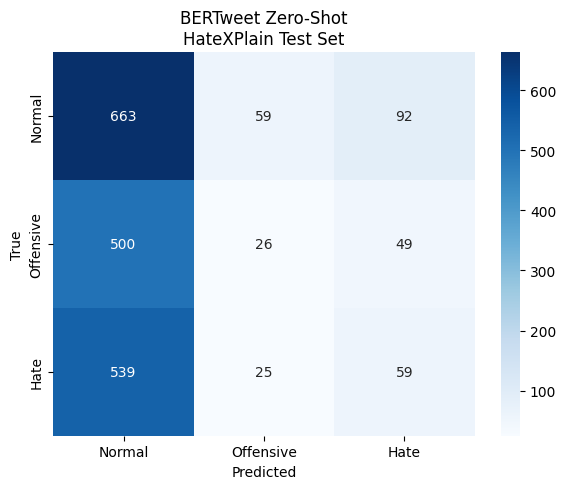

In [10]:
# Confusion Matrix — HateXPlain
cm = confusion_matrix(hx_labels, hx_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Offensive', 'Hate'],
    yticklabels=['Normal', 'Offensive', 'Hate']
)
plt.title('BERTweet Zero-Shot\nHateXPlain Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('bertweet_zeroshot_hatexplain_cm.png', dpi=150)
plt.show()

## 6. Evaluate on TweetEval Test Set

In [11]:
print('Running zero-shot prediction on TweetEval...')
te_preds  = predict_zeroshot(te_test['text'].fillna(''))
te_labels = te_test['label'].values

te_macro_f1 = f1_score(te_labels, te_preds, average='macro')
te_accuracy = accuracy_score(te_labels, te_preds)

print(f'\n=== TweetEval Results ===')
print(f'Accuracy:  {te_accuracy:.4f}')
print(f'Macro F1:  {te_macro_f1:.4f}')
print()
print(classification_report(
    te_labels, te_preds,
    target_names=['Normal', 'Offensive', 'Hate']
))

Running zero-shot prediction on TweetEval...

=== TweetEval Results ===
Accuracy:  0.5023
Macro F1:  0.3446

              precision    recall  f1-score   support

      Normal       0.63      0.66      0.64      2338
   Offensive       0.05      0.09      0.07       240
        Hate       0.37      0.29      0.33      1252

    accuracy                           0.50      3830
   macro avg       0.35      0.35      0.34      3830
weighted avg       0.51      0.50      0.50      3830



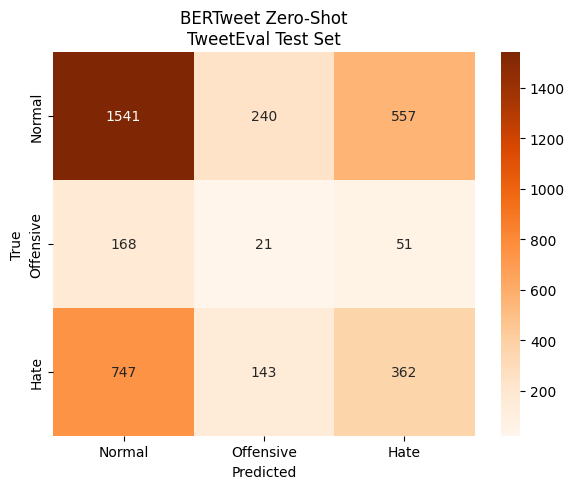

In [12]:
# Confusion Matrix — TweetEval
cm2 = confusion_matrix(te_labels, te_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Normal', 'Offensive', 'Hate'],
    yticklabels=['Normal', 'Offensive', 'Hate']
)
plt.title('BERTweet Zero-Shot\nTweetEval Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('bertweet_zeroshot_tweeteval_cm.png', dpi=150)
plt.show()

## 7. Summary Table

In [13]:
summary = pd.DataFrame({
    'Model':    ['BERTweet (zero-shot)', 'BERTweet (zero-shot)'],
    'Dataset':  ['HateXPlain', 'TweetEval'],
    'Accuracy': [round(hx_accuracy, 4), round(te_accuracy, 4)],
    'Macro F1': [round(hx_macro_f1, 4), round(te_macro_f1, 4)],
})

print(summary.to_string(index=False))
summary.to_csv('bertweet_zeroshot_results.csv', index=False)
print('\nResults saved to bertweet_zeroshot_results.csv')

               Model    Dataset  Accuracy  Macro F1
BERTweet (zero-shot) HateXPlain    0.3718    0.2488
BERTweet (zero-shot)  TweetEval    0.5023    0.3446

Results saved to bertweet_zeroshot_results.csv


## 8. Notes

**Why BERTweet may outperform BERT-base-uncased on TweetEval:**
- Pre-trained on 850M tweets → understands @mentions, hashtags, abbreviations, emoji
- TweetEval data comes from Twitter → domain match

**Why it may still underperform twitter-roberta-base-hate:**
- BERTweet here has no classification-specific fine-tuning
- twitter-roberta-base-hate is already fine-tuned on the hate task